All files necessary for the algorithm to work must be in the data folder.
List of data files:
elliptic_txs_classes.csv
elliptic_txs_edgelist.csv
elliptic_txs_features.csv



Усі необхідні файли для роботи алгоритму повинні знаходитися в папці data. 
Список файлі з даними:
elliptic_txs_classes.csv
elliptic_txs_edgelist.csv
elliptic_txs_features.csv

In [ ]:
# Step 1. Load data.

print("=" * 60)
print("Step 1. Load data.")
print("=" * 60)

import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.expand_frame_repr", False)
pd.set_option("display.max_colwidth", None)

classes = pd.read_csv("data/elliptic_txs_classes.csv")

edgelist = pd.read_csv("data/elliptic_txs_edgelist.csv")

columns = []

# Basic fields
# Основні поля
columns.append("txId")
columns.append("time_step")

# Add 94 local features called local_xx
# Додаємо 94 локальні ознаки під назвою local_xx

for i in range(1, 95):
    # Create the column name
    # Формуємо назву стовпця
    name = "local_"

    # For numbers less than 10, add a leading zero
    # Для чисел менше 10 додаємо нуль попереду
    if i < 10:
        name = name + "0"

    # Add the sign number
    # Додаємо номер ознаки
    name = name + str(i)

    # Add the name to the list
    # Додаємо назву до списку
    columns.append(name)

# Add 71 aggregated (graph) features called agg_xx
# Додаємо 71 агреговані (графові) ознаки під назвою agg_xx

for i in range(1, 72):
    # Create the column name
    # Формуємо назву стовпця
    name = "agg_"

    # For numbers less than 10, add a leading zero
    # Для чисел менше 10 додаємо нуль попереду
    if i < 10:
        name = name + "0"

    # Add the sign number
    # Додаємо номер ознаки
    name = name + str(i)

    # Add the name to the list
    # Додаємо назву до списку
    columns.append(name)

features = pd.read_csv("data/elliptic_txs_features.csv", header=None,  names=columns)


print("\nPrint table features")
print(features.shape)
print(features.head())

# print the column names of the features table
# надрукуємо імена стовпчиків таблиці features
print("\nPrint columns name for table features")
for col in features.columns:
    print(col)

# check the dimensions of the features and classes tables
# перевіримо розмірності таблиць features та classes
print("\nCheck table size of features and classes")
print(features.shape)
print(classes.shape)



Print table features
(203769, 167)
        txId  time_step  local_01  local_02  local_03   local_04  local_05  local_06   local_07  local_08  local_09  local_10  local_11  local_12  local_13  local_14  local_15  local_16  local_17  local_18  local_19  local_20  local_21  local_22  local_23  local_24  local_25  local_26  local_27  local_28  local_29  local_30  local_31  local_32  local_33  local_34  local_35  local_36  local_37  local_38  local_39  local_40  local_41  local_42  local_43  local_44  local_45  local_46  local_47  local_48  local_49  local_50  local_51  local_52  local_53  local_54  local_55  local_56  local_57  local_58  local_59  local_60  local_61  local_62  local_63  local_64  local_65  local_66  local_67  local_68  local_69  local_70  local_71  local_72  local_73  local_74  local_75  local_76  local_77  local_78  local_79  local_80  local_81  local_82  local_83  local_84  local_85  local_86  local_87  local_88  local_89  local_90  local_91  local_92  local_93  local_9

Program code for creating the elliptic_classification table to be used for supervised classification experiments.

Код програми для створення таблиці elliptic_classification, що буде використовуватися для експериментів із контрольованою класифікацією.

In [ ]:
# Step 2. Joining the features and classes tables.
# Об'єднання таблиць features та classes.

print("=" * 60)
print("Step 2. Joining the features and classes tables.")
print("=" * 60)

elliptic_labeled = pd.merge(
    features,
    classes,
    on="txId",
    how="inner"
)

# check elliptic_labeled table
# перевірка таблиці elliptic_labeled
print("\nChecking the table elliptic_labeled");
print(elliptic_labeled.shape)
print(elliptic_labeled.head())

# check number of classes
# перевірка кількість класів
print("\nChecking the number of classes")
print(elliptic_labeled["class"].value_counts())

# data integrity check
# перевірка цілісності даних
print("\nDuplicates:", elliptic_labeled.duplicated().sum())
print("Missing values:")
print(elliptic_labeled.isnull().sum().sum())

# check if no records are lost after merging
# перевірка, чи не втрачено жодного запису після об'єднання
assert len(features) == len(elliptic_labeled)

# check if all txIds are unique
# перевірка, чи всі txId унікальні
print("\nUnique txId :", elliptic_labeled["txId"].nunique())
print("Rows        :", len(elliptic_labeled))

# check for duplicate txIds
# перевірка, чи не має повторних txId
duplicates = elliptic_labeled["txId"].duplicated().sum()
print("\nDuplicated txId:", duplicates)

# create a dataset that will be used for the classification task
# створимо набір даних, який буде використовуватися для задачі класифікації
elliptic_classification = elliptic_labeled[
    elliptic_labeled["class"] != "unknown"
].copy()

# check the elliptic classification table, how many rows and columns
# перевірка таблиці elliptic_classification, скільки строк та стовбчиків
print("\nnumber of rows and columns in elliptic_classification")
print(elliptic_classification.shape)

# the program code replaces the value 2 with 0, and it will now be 0 - licit, and the value 1 is left as 1, and now 1 - illicit
# код програми замінує значення 2 на 0, і це буде тепер 0 - licit, а значення 1 залишаємо як 1, і тепер 1 - illicit
print("\nFurther in the program the notation 0 is licit and 1 is illicit will be used");

elliptic_classification["class"] = (
    elliptic_classification["class"]
    .map({
        "2": 0,
        "1": 1
    })
    .astype(int)
)

# check the number of classes in the elliptic classification table
# перевірка кількість класів в таблиці elliptic_classification
print("\nChecking the number of classes in table elliptic_classification")
print(elliptic_classification["class"].value_counts())


Checking the table elliptic_labeled
(203769, 168)
        txId  time_step  local_01  local_02  local_03   local_04  local_05  local_06   local_07  local_08  local_09  local_10  local_11  local_12  local_13  local_14  local_15  local_16  local_17  local_18  local_19  local_20  local_21  local_22  local_23  local_24  local_25  local_26  local_27  local_28  local_29  local_30  local_31  local_32  local_33  local_34  local_35  local_36  local_37  local_38  local_39  local_40  local_41  local_42  local_43  local_44  local_45  local_46  local_47  local_48  local_49  local_50  local_51  local_52  local_53  local_54  local_55  local_56  local_57  local_58  local_59  local_60  local_61  local_62  local_63  local_64  local_65  local_66  local_67  local_68  local_69  local_70  local_71  local_72  local_73  local_74  local_75  local_76  local_77  local_78  local_79  local_80  local_81  local_82  local_83  local_84  local_85  local_86  local_87  local_88  local_89  local_90  local_91  local_92  lo

Let's prepare the data for analysis. Let's create the following data sets separately: X_train, X_test, y_train, y_test. In the proportion of 80 for training and 20 for testing.

Підготовимо дані для аналізу. Створимо окремо такі набори даних: X_train, X_test, y_train, y_test. У пропорції 80 на тренінг та 20 на тестування.

In [ ]:
# Step 3. Prepare data for machine learning.
# Підготовка даних до задачі машинного навчання.

print("=" * 60)
print("Step 3. Prepare data for machine learning.")
print("=" * 60)

from sklearn.model_selection import train_test_split

# Matrix of features.
# Матриця характеристик.
X = elliptic_classification.drop(columns=["txId", "class"])

# Target variable.
# Цільова змінна.
y = elliptic_classification["class"]

print("\nFeature matrix shape :", X.shape)
print("Target vector shape :", y.shape)

# Split into training and testing datasets
# Розбиття на тренінговий та тестовий набори даних
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining set")
print(X_train.shape)

print("\nTesting set")
print(X_test.shape)


Feature matrix shape : (46564, 166)
Target vector shape : (46564,)

Training set
(37251, 166)

Testing set
(9313, 166)


Creating OOF (Out-of-Fold) arrays. We will train the model five times on different 80% of the training data so that each object receives a prediction from a model that did not use this object during training.

Створення OOF масивів (Out-of-Fold). П'ять разів будемо навчати модель на різних 80 % тренувальних даних, щоб кожен об'єкт отримав прогноз від моделі, яка не використовувала цей об'єкт під час навчання.

In [12]:
# Step 4. Creating OOF (Out-of-Fold) arrays.

print("=" * 60)
print("Step 4. Creating OOF (Out-of-Fold) arrays.")
print("=" * 60)

# Import libraries
# Імпорт бібліотек
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold

# Create Stratified K-Fold

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Create OOF-array

rf_oof = np.zeros(len(X_train))
xgb_oof = np.zeros(len(X_train))
lgbm_oof = np.zeros(len(X_train))
cat_oof = np.zeros(len(X_train))

print("OOF arrays successfully created.")
print("Length:", len(rf_oof))

# After executing this code, all arrays will be filled with zeros.
# Після виконання цього коду всі масиви будуть заповнені нулями.

print(rf_oof.shape)
print(rf_oof)
print("\n\n")

# Step 5. Creating ML models (1) Random Forest; (2) XGBoost; (3) LightGBM; (4) CatBoost.

# OOF (Out-of-Fold) arrays.
# Starting the loop
# Починаємо цикл

for fold, (train_idx, valid_idx) in enumerate(
        skf.split(X_train, y_train), start=1):

    print("=" * 50)
    print(f"Fold {fold}/5")

    X_tr = X_train.iloc[train_idx]
    X_val = X_train.iloc[valid_idx]

    y_tr = y_train.iloc[train_idx]
    y_val = y_train.iloc[valid_idx]

    print("Training samples :", len(train_idx))
    print("Validation samples:", len(valid_idx))

    # ----- Random Forest -----

    from sklearn.ensemble import RandomForestClassifier

    rf = RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X_tr, y_tr)

    rf_oof[valid_idx] = rf.predict_proba(X_val)[:, 1]

    print(f"RF completed for Fold {fold}")


    # ----- XGBoost ------

    from xgboost import XGBClassifier

    scale_pos_weight = (y_tr == 0).sum() / (y_tr == 1).sum()

    xgb = XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1,
        scale_pos_weight=scale_pos_weight
    )

    xgb.fit(X_tr, y_tr)

    xgb_oof[valid_idx] = xgb.predict_proba(X_val)[:, 1]

    print(f"XGBoost completed for Fold {fold}")

    # ----- LightGBM -----

    from lightgbm import LGBMClassifier

    scale_pos_weight = (y_tr == 0).sum() / (y_tr == 1).sum()

    lgbm = LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        max_depth=-1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary",
        random_state=42,
        scale_pos_weight=scale_pos_weight,
        force_col_wise=True,
        n_jobs=-1
    )

    lgbm.fit(X_tr, y_tr)

    lgbm_oof[valid_idx] = lgbm.predict_proba(X_val)[:, 1]

    print(f"LightGBM completed for Fold {fold}")


    # ----- CatBoost -----

    from catboost import CatBoostClassifier

    cat_model = CatBoostClassifier(
        iterations=300,
        learning_rate=0.05,
        depth=6,
        loss_function="Logloss",
        eval_metric="AUC",
        scale_pos_weight=scale_pos_weight,
        random_seed=42,
        thread_count=-1,
        allow_writing_files=False,
        verbose=False
    )

    cat_model.fit(
        X_tr,
        y_tr
    )

    cat_oof[valid_idx] = cat_model.predict_proba(X_val)[:, 1]

    print(f"CatBoost completed for Fold {fold}")


# Output the first 20 values ​​to check for fullness
# Вивід перших 20 значень, для перевірки заповненості
print("\n\nOutput of the first 20 values ​​to check for completeness")
print(rf_oof[:20])
print(xgb_oof[:20])
print(lgbm_oof[:20])
print(cat_oof[:20])

# Array filling control
# Контроль заповнення масивів
print("\n\nArray filling control")

print(np.isnan(rf_oof).sum())
print(np.isnan(xgb_oof).sum())
print(np.isnan(lgbm_oof).sum())
print(np.isnan(cat_oof).sum())

print(np.count_nonzero(rf_oof))
print(np.count_nonzero(xgb_oof))
print(np.count_nonzero(lgbm_oof))
print(np.count_nonzero(cat_oof))

# Output the number of unique probabilities
# Вивід кількість унікальних ймовірностей
print("\n\nDerivation of the number of unique probabilities")
print(len(np.unique(rf_oof)))
print(len(np.unique(xgb_oof)))
print(len(np.unique(lgbm_oof)))
print(len(np.unique(cat_oof)))

# Checking the correctness of the obtained probability values
# Перевірка коректності отриманих значень ймовірностей
print("\n\nChecking the correctness of the obtained probability values")
print(rf_oof.min(), rf_oof.max())
print(xgb_oof.min(), xgb_oof.max())
print(lgbm_oof.min(), lgbm_oof.max())
print(cat_oof.min(), cat_oof.max())

# Building a dataset for meta-learning, combining predicted probabilities (Out-of-fold, OOF) generated by the base classifiers
# Побудова набору даних для мета-навчання, об'єднання прогнозованих ймовірностей (Out-of-fold, OOF), що було згенеровано базовими класифікаторами
meta_train = pd.DataFrame({
    "RF": rf_oof,
    "XGB": xgb_oof,
    "LGBM": lgbm_oof,
    "CAT": cat_oof
})

print("\nMeta-train successfully created.")

print(meta_train.head())

print(meta_train.shape)

Step 4. Creating OOF (Out-of-Fold) arrays.
OOF arrays successfully created.
Length: 37251
(37251,)
[0. 0. 0. ... 0. 0. 0.]



Fold 1/5
Training samples : 29800
Validation samples: 7451
RF completed for Fold 1
XGBoost completed for Fold 1
[LightGBM] [Info] Number of positive: 2908, number of negative: 26892
[LightGBM] [Info] Total Bins 38684
[LightGBM] [Info] Number of data points in the train set: 29800, number of used features: 166
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.097584 -> initscore=-2.224363
[LightGBM] [Info] Start training from score -2.224363
LightGBM completed for Fold 1
CatBoost completed for Fold 1
Fold 2/5
Training samples : 29801
Validation samples: 7450
RF completed for Fold 2
XGBoost completed for Fold 2
[LightGBM] [Info] Number of positive: 2909, number of negative: 26892
[LightGBM] [Info] Total Bins 38636
[LightGBM] [Info] Number of data points in the train set: 29801, number of used features: 166
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.097614 -

Model hyperparameter settings.

Налаштування гіпер-параметрів моделі.

In [9]:
# Tune the regularization parameter of the Logistic Regression meta-model using GridSearchCV. 
# The optimal configuration is selected according to the highest mean F1-score obtained from 5-fold cross-validation.

# Налаштування параметрів регуляризації мета-моделі логістичної регресії за допомогою GridSearchCV. 
# Оптимальна конфігурація вибирається відповідно до найвищого середнього F1-оцінки, отриманого в результаті 5-кратної перехресної перевірки.

# Step 6. Hyperparameter tuning of the meta-model
# Налаштування параметрів регуляризації мета-моделі.

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

print("=" * 60)
print("Step 6. Hyperparameter tuning of Logistic Regression")
print("=" * 60)

# Define the hyperparameter search space
# Визначення простору пошуку гіперпараметрів

param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l2"],
    "solver": ["lbfgs"]
}

# Configure the grid search procedure
# Налаштування процедуру пошуку по сітці

grid_search = GridSearchCV(
    estimator=LogisticRegression(
        random_state=42,
        max_iter=1000
    ),
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Perform hyperparameter optimization on the meta-training dataset
# Використання оптимізації гіперпараметрів на наборі мета-навчальних даних

grid_search.fit(meta_train, y_train)

print("\nBest parameters:")
print(grid_search.best_params_)

print("\nBest CV F1-score:")
print(grid_search.best_score_)

# Retrieve the optimized meta-model
# Отримання оптимізованої метамоделі

meta_model = grid_search.best_estimator_

print("\nOptimized meta-model:")
print(meta_model)

Step 6. Hyperparameter tuning of Logistic Regression
Fitting 5 folds for each of 5 candidates, totalling 25 fits

Best parameters:
{'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}

Best CV F1-score:
0.9569129079825608

Optimized meta-model:
LogisticRegression(C=0.1, max_iter=1000, random_state=42)


After running the previous program code, each model knows the entire training set, not just 80% of the data from one fold.
These models will be used to predict the independent test sample (X_test).

Після виконання попереднього коду програми, кожна модель знає весь навчальний набір, а не лише 80% даних одного fold.
Саме ці моделі будуть використовуватися для прогнозування незалежної тестової вибірки (X_test).

In [10]:
# Step 7. Retrain base models on the full training dataset
# Перенавчити базові моделі на повному навчальному наборі даних

print("=" * 60)
print("Step 7. Retraining base models on the full training set")
print("=" * 60)

# Retrain Random Forest
# Перенавчання моделі Random Forest

from sklearn.ensemble import RandomForestClassifier

rf_final = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_final.fit(X_train, y_train)

print("Random Forest successfully retrained.")

# Retrain XGBoos
# Перенавчання моделі XGBoos

from xgboost import XGBClassifier

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_final = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight
)

xgb_final.fit(X_train, y_train)

print("XGBoost successfully retrained.")

# Retrain LightGBM 
# Перенавчання моделі LightGBM

from lightgbm import LGBMClassifier

lgbm_final = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary",
    random_state=42,
    scale_pos_weight=scale_pos_weight,
    force_col_wise=True,
    n_jobs=-1
)

lgbm_final.fit(X_train, y_train)

print("LightGBM successfully retrained.")

# Retrain CatBoost 
# Перенавчання моделі CatBoost

from catboost import CatBoostClassifier

cat_final = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    loss_function="Logloss",
    eval_metric="AUC",
    scale_pos_weight=scale_pos_weight,
    random_seed=42,
    thread_count=-1,
    allow_writing_files=False,
    verbose=False
)

cat_final.fit(X_train, y_train)

print("CatBoost successfully retrained.")

print("\nAll base models have been successfully retrained.")


Step 7. Retraining base models on the full training set
Random Forest successfully retrained.
XGBoost successfully retrained.
[LightGBM] [Info] Number of positive: 3636, number of negative: 33615
[LightGBM] [Info] Total Bins 38786
[LightGBM] [Info] Number of data points in the train set: 37251, number of used features: 166
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.097608 -> initscore=-2.224088
[LightGBM] [Info] Start training from score -2.224088
LightGBM successfully retrained.
CatBoost successfully retrained.

All base models have been successfully retrained.


Generate class probability estimates for the positive class using the retrained base classifiers. 
These probabilities will serve as meta-features for the stacking ensemble.

Генерування оцінок ймовірностей класу для позитивного класу, використовуючи перенавчені базові класифікатори.
Ці ймовірності слугуватимуть мета-ознаками для ансамблю стекування в подальшому.

In [11]:
# Step 8. Predict probabilities for the test dataset
# Прогнозування ймовірностей для тестового набору даних

print("=" * 60)
print("Step 8. Predict probabilities on X_test")
print("=" * 60)

# ----- Random Forest -----

rf_test_prob = rf_final.predict_proba(X_test)[:, 1]

print("Random Forest predictions completed.")

# ----- XGBoost -----

xgb_test_prob = xgb_final.predict_proba(X_test)[:, 1]

print("XGBoost predictions completed.")

# ----- LightGBM -----

lgbm_test_prob = lgbm_final.predict_proba(X_test)[:, 1]

print("LightGBM predictions completed.")

# ----- CatBoost -----

cat_test_prob = cat_final.predict_proba(X_test)[:, 1]

print("CatBoost predictions completed.")

# Checking results 1
# Перевірка результатів 1

print("\n\nProbability ranges")

print("RF   :", rf_test_prob.min(), rf_test_prob.max())
print("XGB  :", xgb_test_prob.min(), xgb_test_prob.max())
print("LGBM :", lgbm_test_prob.min(), lgbm_test_prob.max())
print("CAT  :", cat_test_prob.min(), cat_test_prob.max())

# Checking results 2
# Перевірка результатів 2

print("\n\nArray lengths")

print(len(rf_test_prob))
print(len(xgb_test_prob))
print(len(lgbm_test_prob))
print(len(cat_test_prob))
print(len(y_test))

Step 8. Predict probabilities on X_test
Random Forest predictions completed.
XGBoost predictions completed.
LightGBM predictions completed.
CatBoost predictions completed.


Probability ranges
RF   : 0.0 1.0
XGB  : 7.0092037e-06 0.9999697
LGBM : 9.871418340725037e-07 0.9999781728972782
CAT  : 1.132251859560562e-06 0.9996016399043532


Array lengths
9313
9313
9313
9313
9313


Construct the meta-test dataset by combining the predicted probabilities generated by all base classifiers. 
This dataset serves as the input for the trained stacking meta-model.

Створення набору метатестів, за рахунок об'єднання прогнозованих ймовірностей, що згенеровані всіма базовими класифікаторами.
Цей набір даних слугує вхідними даними для навченої метамоделі стекування.

In [ ]:
# Step 9. Create meta_test

print("=" * 60)
print("Step 9. Create meta_test")
print("=" * 60)

meta_test = pd.DataFrame({
    "RF": rf_test_prob,
    "XGB": xgb_test_prob,
    "LGBM": lgbm_test_prob,
    "CAT": cat_test_prob
})

print("meta_test successfully created.")

print(meta_test.head())

print(meta_test.shape)

Step 9. Create meta_test
meta_test successfully created.
      RF       XGB      LGBM       CAT
0  0.020  0.002080  0.000323  0.018865
1  0.010  0.029976  0.016676  0.133702
2  0.045  0.323289  0.256820  0.276165
3  0.005  0.000539  0.000089  0.004547
4  0.045  0.000833  0.000143  0.008489
(9313, 4)


Apply the trained stacking meta-model to the meta-test dataset to obtain the final classification results and probability estimates.

Викорисьання навченої мета-моделі стекування до набору даних мета-тесту, щоб отримати кінцеві результати класифікації та оцінки ймовірностей.

In [14]:
# Step 10. Final prediction of the stacking ensemble

print("=" * 60)
print("Step 10. Final prediction")
print("=" * 60)

# Predicted class
# Значення прогнозів класів

meta_pred = meta_model.predict(meta_test)

# Predicted probability
# Значення прогнозів ймовірністей

meta_prob = meta_model.predict_proba(meta_test)[:, 1]

print("Stacking predictions successfully completed.")

# Verification
# Перевірка

print("\nPrediction array length:", len(meta_pred))
print("Probability array length:", len(meta_prob))

print("\nFirst 20 predicted classes:")
print(meta_pred[:20])

print("\nFirst 20 predicted probabilities:")
print(meta_prob[:20])

print("\nProbability range:")
print(meta_prob.min(), meta_prob.max())

print(meta_prob.min(), meta_prob.max())

Step 10. Final prediction
Stacking predictions successfully completed.

Prediction array length: 9313
Probability array length: 9313

First 20 predicted classes:
[0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 1 0 0 0]

First 20 predicted probabilities:
[0.00433423 0.00662481 0.04364249 0.00400657 0.00442844 0.00391828
 0.00390767 0.00391254 0.00393892 0.00408967 0.00470921 0.98889575
 0.0063644  0.99290797 0.00390589 0.00420791 0.99296976 0.02680056
 0.01921989 0.00390633]

Probability range:
0.003905213365761947 0.9930013794561086
0.003905213365761947 0.9930013794561086


Assess the predictive performance of the optimized stacking ensemble by computing evaluation metrics and analyzing the confusion matrix and classification report.

Оцінювання прогностичної ефективності оптимізованого ансамблю стекування шляхом обчислення метрик оцінювання та аналізу матриці плутанини та звіту про класифікацію.

In [15]:
# Step 11. Evaluation of the optimized stacking ensemble

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

import pandas as pd

print("=" * 60)
print("Step 11. Evaluation of the optimized stacking ensemble")
print("=" * 60)

# Calculate evaluation metrics

accuracy = accuracy_score(y_test, meta_pred)

precision = precision_score(y_test, meta_pred)

recall = recall_score(y_test, meta_pred)

f1 = f1_score(y_test, meta_pred)

roc_auc = roc_auc_score(y_test, meta_prob)

pr_auc = average_precision_score(y_test, meta_prob)

# Create results table

stacking_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC",
        "PR-AUC"
    ],
    "Value": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc,
        pr_auc
    ]
})

print("\nStacking Performance")
print(stacking_results.round(6))

# Confusion Matrix

print("\nConfusion Matrix")

cm = confusion_matrix(y_test, meta_pred)

print(cm)

TN, FP, FN, TP = cm.ravel()

print(f"\nTrue Negative : {TN}")
print(f"False Positive: {FP}")
print(f"False Negative: {FN}")
print(f"True Positive : {TP}")

# Classification Report

print("\nClassification Report")

print(classification_report(y_test, meta_pred, digits=6))

Step 11. Evaluation of the optimized stacking ensemble

Stacking Performance
      Metric     Value
0   Accuracy  0.992913
1  Precision  0.985040
2     Recall  0.941694
3   F1-score  0.962880
4    ROC-AUC  0.997945
5     PR-AUC  0.988279

Confusion Matrix
[[8391   13]
 [  53  856]]

True Negative : 8391
False Positive: 13
False Negative: 53
True Positive : 856

Classification Report
              precision    recall  f1-score   support

           0   0.993723  0.998453  0.996083      8404
           1   0.985040  0.941694  0.962880       909

    accuracy                       0.992913      9313
   macro avg   0.989382  0.970074  0.979481      9313
weighted avg   0.992876  0.992913  0.992842      9313



Random Forest

Assess the predictive performance of the Random Forest model by computing evaluation metrics and analyzing the confusion matrix and classification report.

Оцінювання прогностичної ефективності моделі випадкового лісу (Random Forest), обчислюючи метрики оцінювання та аналізуючи матрицю плутанини та будуючи звіт про класифікацію.

In [16]:
# Step 12. Evaluation of Random Forest


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

print("=" * 60)
print("Step 12. Evaluation of Random Forest")
print("=" * 60)

# Prediction
# Прогнози

rf_pred = rf_final.predict(X_test)

rf_prob = rf_final.predict_proba(X_test)[:,1]

print("Prediction completed.")

# Metrics
# Метрики

rf_accuracy = accuracy_score(y_test, rf_pred)

rf_precision = precision_score(y_test, rf_pred)

rf_recall = recall_score(y_test, rf_pred)

rf_f1 = f1_score(y_test, rf_pred)

rf_roc_auc = roc_auc_score(y_test, rf_prob)

rf_pr_auc = average_precision_score(y_test, rf_prob)

# Results table
# Таблиця з результатами

rf_results = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC",
        "PR-AUC"
    ],

    "Value":[
        rf_accuracy,
        rf_precision,
        rf_recall,
        rf_f1,
        rf_roc_auc,
        rf_pr_auc
    ]

})

print("\nRandom Forest Performance")

print(rf_results.round(6))

# Confusion Matrix
# Матриця помилок

print("\nConfusion Matrix")

rf_cm = confusion_matrix(
    y_test,
    rf_pred
)

print(rf_cm)

TN, FP, FN, TP = rf_cm.ravel()

print(f"\nTrue Negative : {TN}")
print(f"False Positive: {FP}")
print(f"False Negative: {FN}")
print(f"True Positive : {TP}")

# Classification Report
# Звіт про результати класифікації

print("\nClassification Report")

print(
    classification_report(
        y_test,
        rf_pred,
        digits=6
    )
)


rf_summary = {
    "Accuracy": rf_accuracy,
    "Precision": rf_precision,
    "Recall": rf_recall,
    "F1-score": rf_f1,
    "ROC-AUC": rf_roc_auc,
    "PR-AUC": rf_pr_auc
}


Step 12. Evaluation of Random Forest
Prediction completed.

Random Forest Performance
      Metric     Value
0   Accuracy  0.987652
1  Precision  0.997494
2     Recall  0.875688
3   F1-score  0.932630
4    ROC-AUC  0.996531
5     PR-AUC  0.981084

Confusion Matrix
[[8402    2]
 [ 113  796]]

True Negative : 8402
False Positive: 2
False Negative: 113
True Positive : 796

Classification Report
              precision    recall  f1-score   support

           0   0.986729  0.999762  0.993203      8404
           1   0.997494  0.875688  0.932630       909

    accuracy                       0.987652      9313
   macro avg   0.992112  0.937725  0.962917      9313
weighted avg   0.987780  0.987652  0.987291      9313



XGBoost

Assess the predictive performance of the XGBoost model by computing evaluation metrics and analyzing the confusion matrix and classification report.

Оцінювання прогностичної ефективності моделі XGBoost, обчислюючи метрики оцінювання та аналізуючи матрицю плутанини та будуючи звіт про класифікацію.

In [17]:
# Step 13. Evaluation of XGBoost

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

print("=" * 60)
print("Step 13. Evaluation of XGBoost")
print("=" * 60)

# Prediction

xgb_pred = xgb_final.predict(X_test)

xgb_prob = xgb_final.predict_proba(X_test)[:,1]

print("Prediction completed.")

# Metrics

xgb_accuracy = accuracy_score(y_test, xgb_pred)

xgb_precision = precision_score(y_test, xgb_pred)

xgb_recall = recall_score(y_test, xgb_pred)

xgb_f1 = f1_score(y_test, xgb_pred)

xgb_roc_auc = roc_auc_score(y_test, xgb_prob)

xgb_pr_auc = average_precision_score(y_test, xgb_prob)

# Results table

xgb_results = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC",
        "PR-AUC"
    ],

    "Value":[
        xgb_accuracy,
        xgb_precision,
        xgb_recall,
        xgb_f1,
        xgb_roc_auc,
        xgb_pr_auc
    ]

})

print("\nXGBoost Performance")

print(xgb_results.round(6))

# Confusion Matrix

print("\nConfusion Matrix")

xgb_cm = confusion_matrix(
    y_test,
    xgb_pred
)

print(xgb_cm)

TN, FP, FN, TP = xgb_cm.ravel()

print(f"\nTrue Negative : {TN}")
print(f"False Positive: {FP}")
print(f"False Negative: {FN}")
print(f"True Positive : {TP}")

# Classification Report

print("\nClassification Report")

print(
    classification_report(
        y_test,
        xgb_pred,
        digits=6
    )
)

# Save summary

xgb_summary = {
    "Accuracy": xgb_accuracy,
    "Precision": xgb_precision,
    "Recall": xgb_recall,
    "F1-score": xgb_f1,
    "ROC-AUC": xgb_roc_auc,
    "PR-AUC": xgb_pr_auc
}

Step 13. Evaluation of XGBoost
Prediction completed.

XGBoost Performance
      Metric     Value
0   Accuracy  0.991839
1  Precision  0.963293
2     Recall  0.952695
3   F1-score  0.957965
4    ROC-AUC  0.998012
5     PR-AUC  0.988367

Confusion Matrix
[[8371   33]
 [  43  866]]

True Negative : 8371
False Positive: 33
False Negative: 43
True Positive : 866

Classification Report
              precision    recall  f1-score   support

           0   0.994889  0.996073  0.995481      8404
           1   0.963293  0.952695  0.957965       909

    accuracy                       0.991839      9313
   macro avg   0.979091  0.974384  0.976723      9313
weighted avg   0.991805  0.991839  0.991819      9313



LightGBM

Assess the predictive performance of the LightGBM model by computing evaluation metrics and analyzing the confusion matrix and classification report.

Оцінювання прогностичної ефективності моделі LightGBM, обчислюючи метрики оцінювання та аналізуючи матрицю плутанини та будуючи звіт про класифікацію.

In [18]:
# Step 14. Evaluation of LightGBM

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

print("=" * 60)
print("Step 14. Evaluation of LightGBM")
print("=" * 60)

# Prediction

lgbm_pred = lgbm_final.predict(X_test)

lgbm_prob = lgbm_final.predict_proba(X_test)[:, 1]

print("Prediction completed.")

# Metrics

lgbm_accuracy = accuracy_score(y_test, lgbm_pred)

lgbm_precision = precision_score(y_test, lgbm_pred)

lgbm_recall = recall_score(y_test, lgbm_pred)

lgbm_f1 = f1_score(y_test, lgbm_pred)

lgbm_roc_auc = roc_auc_score(y_test, lgbm_prob)

lgbm_pr_auc = average_precision_score(y_test, lgbm_prob)

# Results table

lgbm_results = pd.DataFrame({

    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC",
        "PR-AUC"
    ],

    "Value": [
        lgbm_accuracy,
        lgbm_precision,
        lgbm_recall,
        lgbm_f1,
        lgbm_roc_auc,
        lgbm_pr_auc
    ]

})

print("\nLightGBM Performance")

print(lgbm_results.round(6))

# Confusion Matrix

print("\nConfusion Matrix")

lgbm_cm = confusion_matrix(
    y_test,
    lgbm_pred
)

print(lgbm_cm)

TN, FP, FN, TP = lgbm_cm.ravel()

print(f"\nTrue Negative : {TN}")
print(f"False Positive: {FP}")
print(f"False Negative: {FN}")
print(f"True Positive : {TP}")

# Classification Report

print("\nClassification Report")

print(
    classification_report(
        y_test,
        lgbm_pred,
        digits=6
    )
)

# Save summary

lgbm_summary = {
    "Accuracy": lgbm_accuracy,
    "Precision": lgbm_precision,
    "Recall": lgbm_recall,
    "F1-score": lgbm_f1,
    "ROC-AUC": lgbm_roc_auc,
    "PR-AUC": lgbm_pr_auc
}

Step 14. Evaluation of LightGBM
Prediction completed.

LightGBM Performance
      Metric     Value
0   Accuracy  0.992806
1  Precision  0.974099
2     Recall  0.951595
3   F1-score  0.962716
4    ROC-AUC  0.998298
5     PR-AUC  0.989616

Confusion Matrix
[[8381   23]
 [  44  865]]

True Negative : 8381
False Positive: 23
False Negative: 44
True Positive : 865

Classification Report
              precision    recall  f1-score   support

           0   0.994777  0.997263  0.996019      8404
           1   0.974099  0.951595  0.962716       909

    accuracy                       0.992806      9313
   macro avg   0.984438  0.974429  0.979367      9313
weighted avg   0.992759  0.992806  0.992768      9313



CatBoost

Assess the predictive performance of the CatBoost model by computing evaluation metrics and analyzing the confusion matrix and classification report.

Оцінювання прогностичної ефективності моделі CatBoost, обчислюючи метрики оцінювання та аналізуючи матрицю плутанини та будуючи звіт про класифікацію.

In [19]:
# Step 15. Evaluation of CatBoost

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

print("=" * 60)
print("Step 15. Evaluation of CatBoost")
print("=" * 60)

# Prediction

cat_pred = cat_final.predict(X_test)

cat_prob = cat_final.predict_proba(X_test)[:, 1]

print("Prediction completed.")

# Metrics

cat_accuracy = accuracy_score(y_test, cat_pred)

cat_precision = precision_score(y_test, cat_pred)

cat_recall = recall_score(y_test, cat_pred)

cat_f1 = f1_score(y_test, cat_pred)

cat_roc_auc = roc_auc_score(y_test, cat_prob)

cat_pr_auc = average_precision_score(y_test, cat_prob)

# Results table

cat_results = pd.DataFrame({

    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC",
        "PR-AUC"
    ],

    "Value": [
        cat_accuracy,
        cat_precision,
        cat_recall,
        cat_f1,
        cat_roc_auc,
        cat_pr_auc
    ]

})

print("\nCatBoost Performance")

print(cat_results.round(6))

# Confusion Matrix

print("\nConfusion Matrix")

cat_cm = confusion_matrix(
    y_test,
    cat_pred
)

print(cat_cm)

TN, FP, FN, TP = cat_cm.ravel()

print(f"\nTrue Negative : {TN}")
print(f"False Positive: {FP}")
print(f"False Negative: {FN}")
print(f"True Positive : {TP}")

# Classification Report

print("\nClassification Report")

print(
    classification_report(
        y_test,
        cat_pred,
        digits=6
    )
)

# Save summary

cat_summary = {
    "Accuracy": cat_accuracy,
    "Precision": cat_precision,
    "Recall": cat_recall,
    "F1-score": cat_f1,
    "ROC-AUC": cat_roc_auc,
    "PR-AUC": cat_pr_auc
}

Step 15. Evaluation of CatBoost
Prediction completed.

CatBoost Performance
      Metric     Value
0   Accuracy  0.986471
1  Precision  0.909091
2     Recall  0.957096
3   F1-score  0.932476
4    ROC-AUC  0.997171
5     PR-AUC  0.984322

Confusion Matrix
[[8317   87]
 [  39  870]]

True Negative : 8317
False Positive: 87
False Negative: 39
True Positive : 870

Classification Report
              precision    recall  f1-score   support

           0   0.995333  0.989648  0.992482      8404
           1   0.909091  0.957096  0.932476       909

    accuracy                       0.986471      9313
   macro avg   0.952212  0.973372  0.962479      9313
weighted avg   0.986915  0.986471  0.986625      9313



Construct a comprehensive comparison table that summarizes the predictive performance of the base classifiers and the stacking ensemble using the selected evaluation metrics.

Формування фінальної таблиці порівнянь, що містить прогностичну ефективність базових класифікаторів та ансамблю стекування, використовуючи вибрані метрики оцінювання.

In [21]:
# Step 16. Comparative Evaluation of All Models

print("=" * 60)
print("Step 16. Comparative Evaluation of All Models")
print("=" * 60)

# ----- 1. Matrix of statistics

comparison_df = pd.DataFrame({

    "Model":[
        "Random Forest",
        "XGBoost",
        "LightGBM",
        "CatBoost",
        "Stacking Ensemble"
    ],

    "Accuracy":[
        rf_accuracy,
        xgb_accuracy,
        lgbm_accuracy,
        cat_accuracy,
        accuracy
    ],

    "Precision":[
        rf_precision,
        xgb_precision,
        lgbm_precision,
        cat_precision,
        precision
    ],

    "Recall":[
        rf_recall,
        xgb_recall,
        lgbm_recall,
        cat_recall,
        recall
    ],

    "F1-score":[
        rf_f1,
        xgb_f1,
        lgbm_f1,
        cat_f1,
        f1
    ],

    "ROC-AUC":[
        rf_roc_auc,
        xgb_roc_auc,
        lgbm_roc_auc,
        cat_roc_auc,
        roc_auc
    ],

    "PR-AUC":[
        rf_pr_auc,
        xgb_pr_auc,
        lgbm_pr_auc,
        cat_pr_auc,
        pr_auc
    ]

})

print("\n\nTable 1. Statistics.")
print(comparison_df.round(6))

# ----- 2. Confusion Matrix

confusion_df = pd.DataFrame({

    "Model":[
        "Random Forest",
        "XGBoost",
        "LightGBM",
        "CatBoost",
        "Stacking Ensemble"
    ],

    "TN":[
        rf_cm[0,0],
        xgb_cm[0,0],
        lgbm_cm[0,0],
        cat_cm[0,0],
        cm[0,0]
    ],

    "FP":[
        rf_cm[0,1],
        xgb_cm[0,1],
        lgbm_cm[0,1],
        cat_cm[0,1],
        cm[0,1]
    ],

    "FN":[
        rf_cm[1,0],
        xgb_cm[1,0],
        lgbm_cm[1,0],
        cat_cm[1,0],
        cm[1,0]
    ],

    "TP":[
        rf_cm[1,1],
        xgb_cm[1,1],
        lgbm_cm[1,1],
        cat_cm[1,1],
        cm[1,1]
    ]

})

print("\n\nTable 2. Confusion Matrix.")
print(confusion_df)



Step 16. Comparative Evaluation of All Models


Table 1. Statistics.
               Model  Accuracy  Precision    Recall  F1-score   ROC-AUC    PR-AUC
0      Random Forest  0.987652   0.997494  0.875688  0.932630  0.996531  0.981084
1            XGBoost  0.991839   0.963293  0.952695  0.957965  0.998012  0.988367
2           LightGBM  0.992806   0.974099  0.951595  0.962716  0.998298  0.989616
3           CatBoost  0.986471   0.909091  0.957096  0.932476  0.997171  0.984322
4  Stacking Ensemble  0.992913   0.985040  0.941694  0.962880  0.997945  0.988279


Table 2. Confusion Matrix.
               Model    TN  FP   FN   TP
0      Random Forest  8402   2  113  796
1            XGBoost  8371  33   43  866
2           LightGBM  8381  23   44  865
3           CatBoost  8317  87   39  870
4  Stacking Ensemble  8391  13   53  856


Compute the ROC coordinates and visualize the ROC curves of the base classifiers and the stacking ensemble to evaluate and compare their classification performance.

Обчислення ROC-координат та побудова ROC-кривих базових класифікаторів та ансамблю стекування, з метою оцінювання та порівняння їхньої ефективності класифікації. 


Step 17. ROC Curves


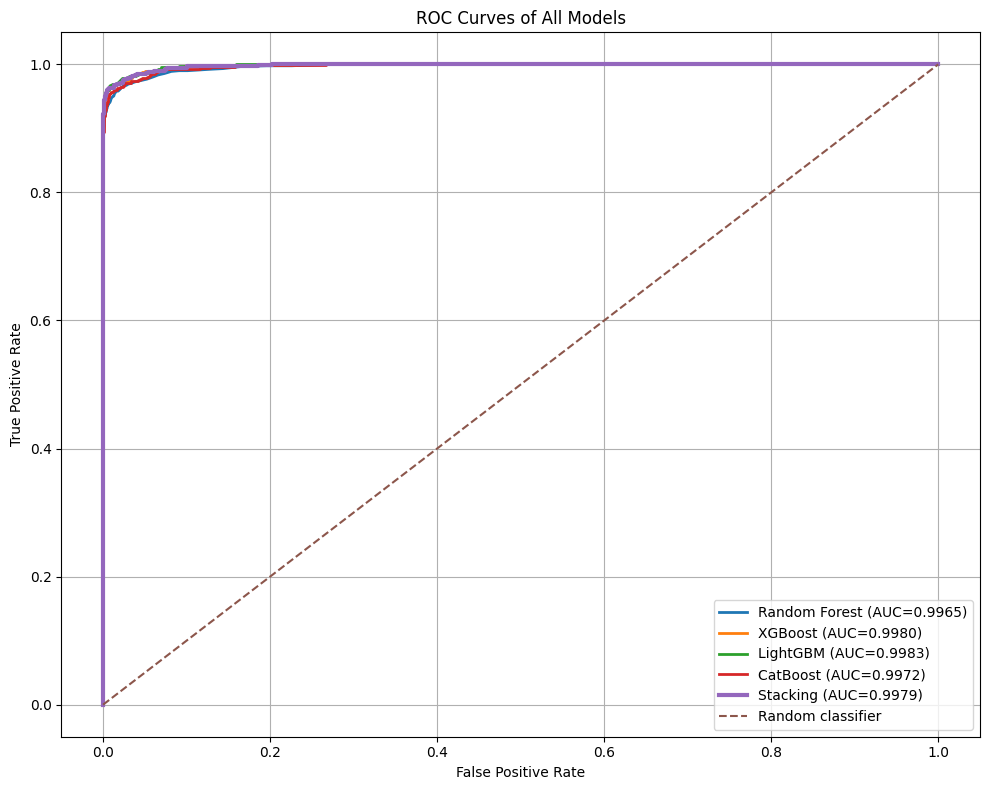

In [23]:
# Step 17. ROC Curves

import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve,
    roc_auc_score
)

print("=" * 60)
print("Step 17. ROC Curves")
print("=" * 60)

# ROC coordinates

rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)

xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_prob)

lgbm_fpr, lgbm_tpr, _ = roc_curve(y_test, lgbm_prob)

cat_fpr, cat_tpr, _ = roc_curve(y_test, cat_prob)

stack_fpr, stack_tpr, _ = roc_curve(y_test, meta_prob)

# Plot

plt.figure(figsize=(10,8))

plt.plot(
    rf_fpr,
    rf_tpr,
    linewidth=2,
    label=f"Random Forest (AUC={rf_roc_auc:.4f})"
)

plt.plot(
    xgb_fpr,
    xgb_tpr,
    linewidth=2,
    label=f"XGBoost (AUC={xgb_roc_auc:.4f})"
)

plt.plot(
    lgbm_fpr,
    lgbm_tpr,
    linewidth=2,
    label=f"LightGBM (AUC={lgbm_roc_auc:.4f})"
)

plt.plot(
    cat_fpr,
    cat_tpr,
    linewidth=2,
    label=f"CatBoost (AUC={cat_roc_auc:.4f})"
)

plt.plot(
    stack_fpr,
    stack_tpr,
    linewidth=3,
    label=f"Stacking (AUC={roc_auc:.4f})"
)

# Random classifier

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    linewidth=1.5,
    label="Random classifier"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curves of All Models")

plt.grid(True)

plt.legend(loc="lower right")

plt.tight_layout()

plt.show()

Implement a universal function for the McNemar statistical test that compares the predictions of two classification models, computes the contingency table, and reports statistical significance.

Реалізація універсальної функції для статистичного тесту МакНемара, яка порівнює прогнози двох моделей класифікації, обчислює таблицю спряженості та повідомляє про статистичну значущість.

In [24]:
# Universal McNemar Test Function

from statsmodels.stats.contingency_tables import mcnemar
import pandas as pd
import numpy as np


def mcnemar_test(
        model1_pred,
        model2_pred,
        y_true,
        model1_name="Model 1",
        model2_name="Model 2",
        correction=True):

    """
    McNemar statistical test for comparing two classifiers.

    Parameters
    ----------
    model1_pred : array-like
        Predictions of the first model.

    model2_pred : array-like
        Predictions of the second model.

    y_true : array-like
        True labels.

    model1_name : str
        Name of the first model.

    model2_name : str
        Name of the second model.

    correction : bool
        Use continuity correction.

    Returns
    -------
    result_dict
        Dictionary containing the test results.
    """

    model1_correct = (model1_pred == y_true)
    model2_correct = (model2_pred == y_true)

    both_correct = np.sum(model1_correct & model2_correct)

    model1_only = np.sum(model1_correct & (~model2_correct))

    model2_only = np.sum((~model1_correct) & model2_correct)

    both_wrong = np.sum((~model1_correct) & (~model2_correct))

    table = [
        [both_correct, model1_only],
        [model2_only, both_wrong]
    ]

    result = mcnemar(
        table,
        exact=False,
        correction=correction
    )

    print("=" * 60)
    print(f"McNemar Test")
    print(f"{model1_name}  vs  {model2_name}")
    print("=" * 60)

    print("\nContingency Table")

    contingency_df = pd.DataFrame(
        table,
        index=[
            f"{model1_name} Correct",
            f"{model1_name} Wrong"
        ],
        columns=[
            f"{model2_name} Correct",
            f"{model2_name} Wrong"
        ]
    )

    print(contingency_df)

    print("\nStatistic :", round(result.statistic, 6))
    print("p-value   :", round(result.pvalue, 8))

    if result.pvalue < 0.05:
        print("\nResult: Statistically significant difference.")
    else:
        print("\nResult: No statistically significant difference.")

    return {
        "Model 1": model1_name,
        "Model 2": model2_name,
        "Statistic": result.statistic,
        "p-value": result.pvalue,
        "Both Correct": both_correct,
        "Only Model 1 Correct": model1_only,
        "Only Model 2 Correct": model2_only,
        "Both Wrong": both_wrong
    }

Apply the McNemar statistical test to compare the stacking ensemble with each base classifier individually and determine whether the differences in their predictions are statistically significant.

Визов статистичного тесту МакНемара, з метою порівняння ансамблю стекування з кожним базовим класифікатором окремо та визначення, чи є відмінності в їхніх прогнозах статистично значущими.

In [26]:
# Step 18. McNemar statistical test to compare the stacking ensemble with each base classifier individually.

print("=" * 60)
print("Step 18. McNemar statistical test to compare the stacking ensemble with each base classifier individually ")
print("=" * 60)

# Random Forest vs Stacking

rf_vs_stack = mcnemar_test(
    rf_pred,
    meta_pred,
    y_test,
    "Random Forest",
    "Stacking"
)


# XGBoost vs Stacking

xgb_vs_stack = mcnemar_test(
    xgb_pred,
    meta_pred,
    y_test,
    "XGBoost",
    "Stacking"
)

# LightGBM vs Stacking

lgbm_vs_stack = mcnemar_test(
    lgbm_pred,
    meta_pred,
    y_test,
    "LightGBM",
    "Stacking"
)

# CatBoost vs Stacking

cat_vs_stack = mcnemar_test(
    cat_pred,
    meta_pred,
    y_test,
    "CatBoost",
    "Stacking"
)




Step 18. McNemar statistical test to compare the stacking ensemble with each base classifier individually 
McNemar Test
Random Forest  vs  Stacking

Contingency Table
                       Stacking Correct  Stacking Wrong
Random Forest Correct              9186              12
Random Forest Wrong                  61              54

Statistic : 31.561644
p-value   : 2e-08

Result: Statistically significant difference.
McNemar Test
XGBoost  vs  Stacking

Contingency Table
                 Stacking Correct  Stacking Wrong
XGBoost Correct              9226              11
XGBoost Wrong                  21              55

Statistic : 2.53125
p-value   : 0.11161177

Result: No statistically significant difference.
McNemar Test
LightGBM  vs  Stacking

Contingency Table
                  Stacking Correct  Stacking Wrong
LightGBM Correct              9236              10
LightGBM Wrong                  11              56

Statistic : 0.0
p-value   : 1.0

Result: No statistically significant 

Create a summary table of the results of the McNemar statistical test, formatting the test statistic, p-value, and significance levels for each model comparison.

Створення зведенної таблиці результатів статистичного тесту МакНемара, відформатувавши статистику тесту, p-значення та показники значущості для кожного порівняння моделей.

In [27]:
# Step 19. Summary Table of McNemar Tests

print("=" * 60)
print("Step 19. Summary of McNemar Tests")
print("=" * 60)

mcnemar_results = pd.DataFrame([
    rf_vs_stack,
    xgb_vs_stack,
    lgbm_vs_stack,
    cat_vs_stack
])

# ----------------------------------------------------------
# Add significance column
# ----------------------------------------------------------

mcnemar_results["Significant"] = np.where(
    mcnemar_results["p-value"] < 0.05,
    "Yes",
    "No"
)

# ----------------------------------------------------------
# Scientific formatting of p-values
# ----------------------------------------------------------

def format_pvalue(p):

    if p < 1e-4:
        return f"{p:.2e}"

    return f"{p:.6f}"

mcnemar_results["p-value"] = (
    mcnemar_results["p-value"]
    .apply(format_pvalue)
)

# ----------------------------------------------------------
# Round statistic
# ----------------------------------------------------------

mcnemar_results["Statistic"] = (
    mcnemar_results["Statistic"]
    .round(3)
)

# ----------------------------------------------------------
# Select columns
# ----------------------------------------------------------

mcnemar_results = mcnemar_results[[
    "Model 1",
    "Model 2",
    "Statistic",
    "p-value",
    "Significant"
]]

from IPython.display import display

display(mcnemar_results)

Step 19. Summary of McNemar Tests


,Model 1,Model 2,Statistic,p-value,Significant
0,Random Forest,Stacking,31.562,1.93e-08,Yes
1,XGBoost,Stacking,2.531,0.111612,No
2,LightGBM,Stacking,0.000,1.000000,No
3,CatBoost,Stacking,38.678,5.00e-10,Yes
